# Computational Set: Open-System Jaynes-Cummings Dynamics

[Jay Foley, Associate Professor of Chemistry, University of North Carolina Charlotte](https://foleylab.github.io/)

In this notebook, we simplify the two-qubit cavity model to a **single qubit coupled to a single bosonic cavity mode**.  We first evolve the density matrix under the unitary Jaynes-Cummings Hamiltonian, then add dissipative dynamics using the **Lindblad master equation**.

The goal is to illustrate how coherent light-matter exchange is modified by:
- cavity photon loss,
- qubit spontaneous emission,
- qubit pure dephasing.


![Atom-Cavity System](images/cavity_atom_schematic.png)

The physical picture is a two-level matter system interacting with a quantized cavity mode.  In this simplified model, the Hilbert space is

$$
\mathscr{H}_{\rm total}=\mathscr{H}_{\rm cav}\otimes\mathscr{H}_{\rm qubit}.
$$


# 🧩 Step 1: Defining the Hamiltonian

## 🎯 Learning Outcomes
By the end of this notebook, you should be able to:

- Represent a single qubit and a truncated cavity mode in a tensor-product basis.
- Build the Jaynes-Cummings Hamiltonian in the composite Hilbert space.
- Propagate a density matrix using the Liouville-von Neumann equation.
- Add open-system effects using Lindblad jump operators.
- Interpret population loss, decoherence, trace preservation, and purity decay.

---

## 🧮 Representing the states of our system

We represent the cavity using the truncated photon-number basis

$$
|0\rangle =
\begin{bmatrix}
1 \\
0
\end{bmatrix},
\qquad
|1\rangle =
\begin{bmatrix}
0 \\
1
\end{bmatrix},
$$

and the qubit using

$$
|g\rangle =
\begin{bmatrix}
1 \\
0
\end{bmatrix},
\qquad
|e\rangle =
\begin{bmatrix}
0 \\
1
\end{bmatrix}.
$$

The uncoupled product basis is

$$
\begin{align}
|0g\rangle &= |0\rangle\otimes|g\rangle, \\
|0e\rangle &= |0\rangle\otimes|e\rangle, \\
|1g\rangle &= |1\rangle\otimes|g\rangle, \\
|1e\rangle &= |1\rangle\otimes|e\rangle.
\end{align}
$$


## 🔬 The Jaynes-Cummings Hamiltonian

For one qubit coupled to one cavity mode, the Jaynes-Cummings Hamiltonian is

$$
H =
-\frac{\hbar \omega_0}{2}\sigma_z
+ \hbar\omega a^\dagger a
+ \hbar g\left(a\sigma_+ + a^\dagger\sigma_-\right).
$$

The terms are:

1. **Bare qubit energy**
   $$
   H_{\rm qubit} = -\frac{\hbar\omega_0}{2}\sigma_z.
   $$

2. **Bare cavity energy**
   $$
   H_{\rm cav}=\hbar\omega a^\dagger a.
   $$

3. **Light-matter coupling**
   $$
   H_{\rm int}=\hbar g\left(a\sigma_+ + a^\dagger\sigma_-\right).
   $$

The interaction conserves the total number of excitations.  Starting from $|0e\rangle$, the qubit excitation can coherently move into the cavity, producing Rabi oscillations between $|0e\rangle$ and $|1g\rangle$.


## 🧮 Step 2: Building the Basis States

We now explicitly construct the uncoupled product basis using `np.kron`.

The ordering convention used throughout the notebook is:

$$
\text{total state} = \text{cavity state}\otimes\text{qubit state}.
$$


In [13]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

# Define the Hamiltonian parameters
omega_0 = 1.0  # qubit frequency
omega = 1.0    # cavity frequency
g = 0.1        # light-matter coupling strength
hbar = 1.0     # set hbar = 1 for convenience

# --- Basis vectors for individual subsystems ---
z_ket = np.array([[1.0], [0.0]])  # |0> cavity state
o_ket = np.array([[0.0], [1.0]])  # |1> cavity state

g_ket = np.array([[1.0], [0.0]])  # |g> qubit ground state
e_ket = np.array([[0.0], [1.0]])  # |e> qubit excited state

# --- Tensor products to build composite states ---
zg_ket = np.kron(z_ket, g_ket)  # |0> ⊗ |g>
ze_ket = np.kron(z_ket, e_ket)  # |0> ⊗ |e>
og_ket = np.kron(o_ket, g_ket)  # |1> ⊗ |g>
oe_ket = np.kron(o_ket, e_ket)  # |1> ⊗ |e>

basis_kets = [zg_ket, ze_ket, og_ket, oe_ket]
basis_names = [r"|0g>", r"|0e>", r"|1g>", r"|1e>"]

print("Basis states:")
for name, ket in zip(basis_names, basis_kets):
    print(f"{name}: \n\n{ket}\n")


Basis states:
|0g>: 

[[1.]
 [0.]
 [0.]
 [0.]]

|0e>: 

[[0.]
 [1.]
 [0.]
 [0.]]

|1g>: 

[[0.]
 [0.]
 [1.]
 [0.]]

|1e>: 

[[0.]
 [0.]
 [0.]
 [1.]]



## Step 3: Constructing the Operators

We use the following qubit operators:

$$
\sigma_z =
\begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix},
\qquad
\sigma_- =
\begin{bmatrix}
0 & 1 \\
0 & 0
\end{bmatrix},
\qquad
\sigma_+ =
\begin{bmatrix}
0 & 0 \\
1 & 0
\end{bmatrix}.
$$

For the truncated cavity mode,

$$
a =
\begin{bmatrix}
0 & 1 \\
0 & 0
\end{bmatrix},
\qquad
a^\dagger =
\begin{bmatrix}
0 & 0 \\
1 & 0
\end{bmatrix}.
$$


In [2]:
# --- Pauli and ladder operators for the qubit ---
sigma_z = np.array([[1.0, 0.0], [0.0, -1.0]])
sigma_minus = np.array([[0.0, 1.0], [0.0, 0.0]])
sigma_plus = sigma_minus.conj().T

# --- Ladder operators for the truncated cavity ---
a = np.array([[0.0, 1.0], [0.0, 0.0]])
adag = a.conj().T

# --- Identities ---
Icav = np.eye(2)
Iq = np.eye(2)

print("sigma_z:\n", sigma_z)
print("sigma_minus:\n", sigma_minus)
print("sigma_plus:\n", sigma_plus)
print("a:\n", a)
print("adag:\n", adag)


sigma_z:
 [[ 1.  0.]
 [ 0. -1.]]
sigma_minus:
 [[0. 1.]
 [0. 0.]]
sigma_plus:
 [[0. 0.]
 [1. 0.]]
a:
 [[0. 1.]
 [0. 0.]]
adag:
 [[0. 0.]
 [1. 0.]]


## 🧱 Building Operators in the Composite Hilbert Space

Each subsystem is two-dimensional, so the total dimension is

$$
2\times 2 = 4.
$$

To make an operator act on the full space, we tensor it with an identity on the subsystem it should not affect:

$$
a_{\rm full}=a\otimes I_q,
\qquad
a^\dagger_{\rm full}=a^\dagger\otimes I_q,
$$

$$
\sigma_{z,{\rm full}}=I_{\rm cav}\otimes\sigma_z,
\qquad
\sigma_{\pm,{\rm full}}=I_{\rm cav}\otimes\sigma_\pm.
$$


In [3]:
# --- Operators in the full cavity ⊗ qubit Hilbert space ---
am = np.kron(a, Iq)
ap = np.kron(adag, Iq)

sz = np.kron(Icav, sigma_z)
sm = np.kron(Icav, sigma_minus)
sp = np.kron(Icav, sigma_plus)

n_cav = ap @ am
qubit_excited_projector = sp @ sm

print("Full-space operator dimension:", am.shape)


Full-space operator dimension: (4, 4)


## ⚡ Step 4: Hamiltonian Terms

Using the full-space operators, the Hamiltonian is

$$
H =
-\frac{\hbar\omega_0}{2}\sigma_z
+ \hbar\omega a^\dagger a
+ \hbar g\left(a\sigma_+ + a^\dagger\sigma_-\right).
$$

Because all operators are already represented in the full composite Hilbert space, the products in the interaction term are ordinary matrix products.


In [4]:
# --- Build the Jaynes-Cummings Hamiltonian ---
H = -hbar * omega_0 / 2 * sz
H += hbar * omega * n_cav
H += hbar * g * (am @ sp + ap @ sm)

print("H shape:", H.shape)
print("Hermitian check:", np.allclose(H, H.conj().T))

# Optional: inspect eigenvalues
energies, eigvecs = la.eigh(H)
print("Eigenvalues:")
print(energies)


H shape: (4, 4)
Hermitian check: True
Eigenvalues:
[-0.5  0.4  0.6  1.5]


## 🌱 Step 5: Defining the Initial State

We start with the cavity empty and the qubit excited:

$$
|\psi(0)\rangle = |0\rangle_{\rm cav}\otimes|e\rangle_{\rm q}=|0e\rangle.
$$

The density matrix is

$$
\rho(0)=|0e\rangle\langle 0e|.
$$

This is a pure state with trace 1 and purity $\mathrm{Tr}(\rho^2)=1$.


In [5]:
# --- Initial condition: |0e> ---
psi0 = ze_ket
rho0 = psi0 @ psi0.conj().T

print("Shape of psi0:", psi0.shape)
print("Norm squared:", np.vdot(psi0, psi0))
print("Density matrix shape:", rho0.shape)
print("Trace(rho0) =", np.trace(rho0))
print("Purity Tr(rho0^2) =", np.real(np.trace(rho0 @ rho0)))


Shape of psi0: (4, 1)
Norm squared: 1.0
Density matrix shape: (4, 4)
Trace(rho0) = 1.0
Purity Tr(rho0^2) = 1.0


## ⏱️ Step: Time-Domain Simulation — Jaynes-Cummings Dynamics with Lindblad Dissipation

For closed-system unitary dynamics, the density matrix obeys the Liouville-von Neumann equation:

$$
\frac{d\rho}{dt} = -\frac{i}{\hbar}[H,\rho].
$$

To model an **open quantum system**, we add Lindblad dissipators:

$$
\frac{d\rho}{dt}
=
-\frac{i}{\hbar}[H,\rho]
+
\sum_j \gamma_j
\left(
L_j \rho L_j^\dagger
-
\frac{1}{2}
\left\{
L_j^\dagger L_j,\rho
\right\}
\right).
$$

Here:

- $L_j$ is a **jump operator** describing one dissipative channel.
- $\gamma_j$ is the rate for that channel.
- $\{A,B\}=AB+BA$ is the anticommutator.

For this single-qubit/cavity model, useful jump operators are:

| Process | Rate | Jump operator | Physical meaning |
|---|---:|---|---|
| Cavity loss | $\kappa$ | $L_\kappa = a$ | A photon leaks out of the cavity: $|1\rangle\rightarrow |0\rangle$ |
| Qubit spontaneous emission | $\gamma_1$ | $L_{\gamma_1}=\sigma_-$ | The qubit relaxes: $|e\rangle\rightarrow |g\rangle$ |
| Qubit pure dephasing | $\gamma_\phi$ | $L_{\phi}=\sigma_+ \sigma_-$ | The relative phase between $|g\rangle$ and $|e\rangle$ is randomized without changing populations |

In the code below, these operators are the **full-space** operators:

$$
a \rightarrow a\otimes I_q,
\qquad
\sigma_- \rightarrow I_{\rm cav}\otimes\sigma_-,
\qquad
\sigma^+ \sigma^- \rightarrow I_{\rm cav}\otimes\sigma_+ \sigma_-.
$$

A small convention note: when using $L_\phi=\sigma_z$, the off-diagonal qubit coherence decays at twice the coefficient multiplying the Lindblad dissipator.  Therefore, the code below uses `gamma_phi / 2` as the Lindblad rate if we want `gamma_phi` to represent the physical pure-dephasing contribution to the coherence decay rate.


In [14]:
def commutator(A, B):
    """Compute the commutator [A, B] = AB - BA."""
    return A @ B - B @ A

def anticommutator(A, B):
    """Compute the anticommutator {A, B} = AB + BA."""
    return A @ B + B @ A

def liouville_rhs(H, rho, hbar=1.0):
    """Unitary part of the density-matrix equation of motion."""
    return -1j / hbar * commutator(H, rho)

def lindblad_rhs(rho, rates=None, jump_ops=None):
    """
    Lindblad dissipative contribution to d rho / dt.

    Parameters
    ----------
    rho : np.ndarray
        Current density matrix.
    rates : list or array of float
        Lindblad rates gamma_j.
    jump_ops : list of np.ndarray
        Jump operators L_j, represented in the full Hilbert space.

    Returns
    -------
    drho_dt : np.ndarray
        Dissipative contribution:
        sum_j gamma_j * (L rho L† - 1/2 {L†L, rho})
    """
    if rates is None or jump_ops is None:
        return np.zeros_like(rho, dtype=complex)

    if len(rates) != len(jump_ops):
        raise ValueError("rates and jump_ops must have the same length.")

    drho_dt = np.zeros_like(rho, dtype=complex)

    #<-- Insert code here to loop over gammas and L operators
    #<-- and evaluate the contribution to the dissipation from each one.

    return drho_dt

def master_rhs(H, rho, rates=None, jump_ops=None, hbar=1.0):
    """Full Lindblad master-equation right-hand side."""
    return liouville_rhs(H, rho, hbar=hbar) + lindblad_rhs(
        rho, rates=rates, jump_ops=jump_ops
    )

def rk4_step(rho, H, dt, rates=None, jump_ops=None, hbar=1.0):
    """
    Apply a single RK4 step to evolve rho under unitary and Lindblad dynamics.
    """
    k1 = master_rhs(H, rho, rates=rates, jump_ops=jump_ops, hbar=hbar)
    k2 = master_rhs(H, rho + 0.5 * dt * k1, rates=rates, jump_ops=jump_ops, hbar=hbar)
    k3 = master_rhs(H, rho + 0.5 * dt * k2, rates=rates, jump_ops=jump_ops, hbar=hbar)
    k4 = master_rhs(H, rho + dt * k3, rates=rates, jump_ops=jump_ops, hbar=hbar)

    rho_next = rho + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    # Numerical cleanup: preserve Hermiticity to within RK/integration error.
    rho_next = 0.5 * (rho_next + rho_next.conj().T)

    return rho_next


## 🕒 Step 6: Simulating Open-System Dynamics

We now choose dissipative rates and propagate the density matrix.

The jump operators are:

```python
jump_ops = [am, sm, sp @ sm]
rates = [kappa, gamma1, gamma_phi / 2]
```

where:

- `am` is cavity photon loss,
- `sm` is qubit spontaneous emission,
- `sp @ sm` is qubit pure dephasing.

Set any rate to zero to remove that dissipative channel.


In [16]:
# --- Dissipation parameters ---
kappa = 0.005      # cavity photon loss rate
gamma1 = 0.002     # qubit spontaneous emission rate
gamma_phi = 0.003  # physical pure-dephasing rate for qubit coherences

jump_ops = [am, sm, sz]
rates = [kappa, gamma1, gamma_phi / 2]

# --- Time-grid parameters ---
dt = 0.05
n_time = 800

# --- Initial condition ---
rho = np.copy(rho0)

# --- Storage arrays ---
t = np.zeros(n_time)
pops = np.zeros((n_time, rho.shape[0]))
trace_rho = np.zeros(n_time, dtype=complex)
purity = np.zeros(n_time)
cavity_photon_number = np.zeros(n_time)
qubit_excited_population = np.zeros(n_time)

# --- Time evolution ---
for i in range(n_time):
    t[i] = i * dt

    # Store observables before taking the next step
    pops[i, :] = np.real(np.diag(rho))
    trace_rho[i] = np.trace(rho)
    purity[i] = np.real(np.trace(rho @ rho))
    cavity_photon_number[i] = np.real(np.trace(rho @ n_cav))
    qubit_excited_population[i] = np.real(np.trace(rho @ qubit_excited_projector))

    rho = rk4_step(rho, H, dt, rates=rates, jump_ops=jump_ops, hbar=hbar)

rho_final = rho

print("Simulation complete!")
print("Final time:", t[-1])
print("Trace(rho_final) =", np.trace(rho_final))
print("Purity Tr(rho_final^2) =", np.real(np.trace(rho_final @ rho_final)))


Simulation complete!
Final time: 39.95
Trace(rho_final) = (0.999999999999998+0j)
Purity Tr(rho_final^2) = 0.9999999999944413


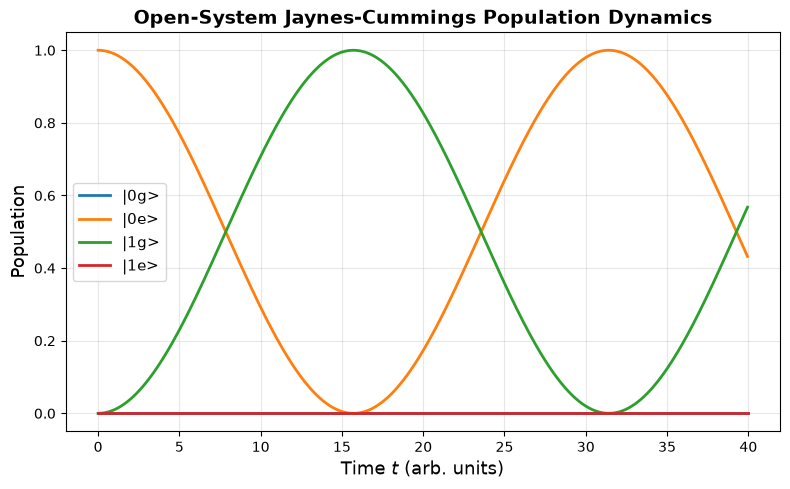

In [17]:
# 🎨 Visualize populations in the uncoupled basis

plt.figure(figsize=(8, 5))

for idx, name in enumerate(basis_names):
    plt.plot(t, pops[:, idx], lw=2.0, label=name)

plt.xlabel(r"Time $t$ (arb. units)", fontsize=13)
plt.ylabel("Population", fontsize=13)
plt.title("Open-System Jaynes-Cummings Population Dynamics", fontsize=14, weight="bold")
plt.grid(alpha=0.3)
plt.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.show()


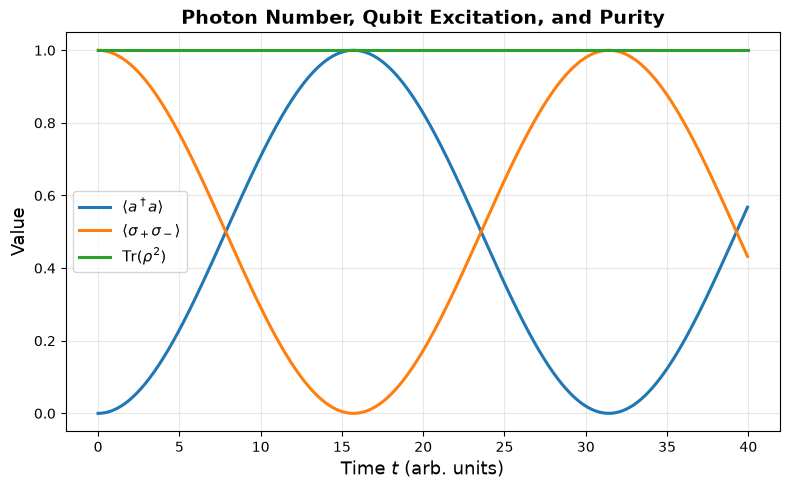

In [18]:
# 🎨 Visualize expectation values and purity

plt.figure(figsize=(8, 5))

plt.plot(t, cavity_photon_number, lw=2.2, label=r"$\langle a^\dagger a\rangle$")
plt.plot(t, qubit_excited_population, lw=2.2, label=r"$\langle \sigma_+\sigma_-\rangle$")
plt.plot(t, purity, lw=2.2, label=r"$\mathrm{Tr}(\rho^2)$")

plt.xlabel(r"Time $t$ (arb. units)", fontsize=13)
plt.ylabel("Value", fontsize=13)
plt.title("Photon Number, Qubit Excitation, and Purity", fontsize=14, weight="bold")
plt.grid(alpha=0.3)
plt.legend(fontsize=11, frameon=True)
plt.tight_layout()
plt.show()


## 💭 Reflection Questions

1. What happens to the Rabi oscillations as `kappa`, `gamma1`, or `gamma_phi` increase?
2. Which dissipative channels change the populations directly?
3. Which dissipative channel primarily destroys coherence without directly changing populations?
4. Why should the trace of $\rho$ remain close to 1 during Lindblad evolution?
5. How does the purity $\mathrm{Tr}(\rho^2)$ distinguish coherent unitary evolution from dissipative open-system evolution?
